# What one description conveys to each observer: figures

Companion notebook to `supplement-ot.tex` and the paper *Rate, Leakage, and Distortion for Gaussian Sources:
Water-Filling on a Tilted Weight* (`tit-rate-leakage.tex`).

**Part 1** draws exact figures from the paper's Gaussian instances.
**Part 2** tests two flips on two public datasets. Every prediction is computed on a training half from second-order
statistics only, *before* any compression. Every outcome is measured on the held-out half with real fixed-rate quantizers.

* **Flip A (one consumer).** At matched bits, the code that reconstructs the whole source worse serves the decoder better.
  Boundary: no flip when the decoder's read is aligned with the source's energy.
* **Flip B (two observers).** At matched bits, the code that reconstructs the decoder's target worse conveys less to a
  second party that holds its own view. Boundary (paper, Corollary context): no flip when the second party's view is
  uncorrelated with the decoder's principal read.

Leakage on data is measured operationally: the held-out cross-entropy, in bits, of the best of three classifiers that
predict the code index from the second party's view. It is an upper bound on H(M|S) achieved by an actual adversary.

In [1]:
import io, math, zipfile, urllib.request, warnings
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.linalg import eigh
from scipy.optimize import brentq
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
warnings.filterwarnings("ignore")
plt.rcParams.update({"font.family": "serif", "font.size": 10, "figure.dpi": 110, "savefig.dpi": 300})
LN2 = math.log(2)
rng = np.random.default_rng(20261001)
print("numpy", np.__version__, "| matplotlib", matplotlib.__version__)

numpy 2.5.3 | matplotlib 3.11.2


## Gaussian helpers (the paper's formulas)

In [2]:
def msqrt(M, inv=False):
    w, U = np.linalg.eigh(M); w = np.clip(w, 1e-300 if inv else 0, None)
    return U @ np.diag(w ** (-0.5 if inv else 0.5)) @ U.T

def Phi(A):   # reverse water-filling at level one on the spectrum of A (Theorem tilted)
    w, E = np.linalg.eigh(0.5 * (A + A.T))
    return E @ np.diag([1.0 if l <= 1 else 1.0 / l for l in w]) @ E.T

def costs(S, J, Se0):   # rate and leakage in bits (Proposition posterior)
    K = np.linalg.inv(np.linalg.inv(S) + J); Se = np.linalg.inv(np.linalg.inv(Se0) + J)
    ld = lambda M: np.linalg.slogdet(M)[1] / LN2
    return 0.5 * (ld(S) - ld(Se0)), 0.5 * (ld(K) - ld(Se))

def frontier_point(S, Q, H, SU, D, alpha, iters=400):   # Proposition mm: monotone water-filling iteration
    Sh = msqrt(S); Qt = Sh @ Q @ Sh; Ht = H @ Sh; X = np.eye(S.shape[0])
    for _ in range(iters):
        T = (1 - alpha) * Ht.T @ np.linalg.inv(Ht @ X @ Ht.T + SU) @ Ht
        nu = math.exp(brentq(lambda l: np.trace(Qt @ Phi(2 * math.exp(l) * Qt + T)) - D, -40, 40))
        Xn = Phi(2 * nu * Qt + T)
        if np.linalg.norm(Xn - X) < 1e-12: X = Xn; break
        X = Xn
    return Sh @ X @ Sh

def gstar(rho2, tau2, D):   # Corollary scalar
    s = 1 + tau2; a = D * s; b = -(D + s - rho2); c = 1 - rho2
    return (-b + math.sqrt(b * b - 4 * a * c)) / (2 * a)

def onedim_direction(S, Q, J, F, D):   # Theorem onedim: top generalized eigenvector of (A(Delta), K)
    K = np.linalg.inv(np.linalg.inv(S) + J); Delta = np.trace(Q @ S) - D
    w, V = eigh(S @ Q @ S - Delta * S, K); b = V[:, -1]
    e = F @ S @ b; return math.degrees(math.atan2(e[1], e[0])) % 180

def coupled():
    u = np.array([math.cos(math.radians(50)), math.sin(math.radians(50))])
    S = np.zeros((3, 3)); S[:2, :2] = np.diag([1.0, 0.4]); S[:2, 2] = S[2, :2] = 0.6 * u; S[2, 2] = 1.0
    F = np.zeros((2, 3)); F[:, :2] = np.eye(2); H = np.array([[0.0, 0.0, 1.0]]); SU = np.array([[0.05]])
    return S, F, F.T @ F, H, SU, H.T @ np.linalg.inv(SU) @ H

# Part 1. Exact figures from the paper's instances

**Figure 1. What a description conveys to an observer is not fixed by what the observer sees.**
The two scalar sources below have the same joint law of (Y, S) up to a scaling of S, yet different least leakage at
every budget. The encoder's view of the context makes the difference (paper, Section X; supplement, Section 3).

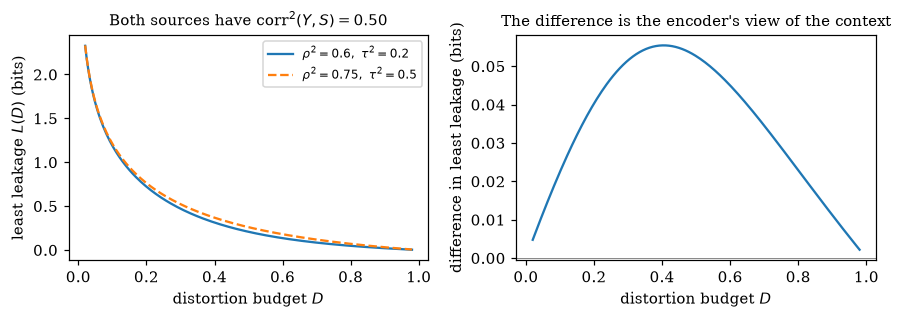

L at D=0.1: 1.1743 (nearest grid point); exact: [1.188, 1.2105]


In [3]:
Ds = np.linspace(0.02, 0.98, 200)
L1 = np.array([0.5 * math.log2(gstar(0.6, 0.2, D)) for D in Ds]); L2 = np.array([0.5 * math.log2(gstar(0.75, 0.5, D)) for D in Ds])
fig, (ax, bx) = plt.subplots(1, 2, figsize=(8.2, 3.0))
ax.plot(Ds, L1, "-", label=r"$\rho^2=0.6,\ \tau^2=0.2$"); ax.plot(Ds, L2, "--", label=r"$\rho^2=0.75,\ \tau^2=0.5$")
ax.set_xlabel("distortion budget $D$"); ax.set_ylabel("least leakage $L(D)$ (bits)"); ax.legend(fontsize=8)
ax.set_title("Both sources have corr$^2(Y,S)=0.50$", fontsize=10)
bx.plot(Ds, L2 - L1, "-"); bx.axhline(0, color="gray", lw=0.6)
bx.set_xlabel("distortion budget $D$"); bx.set_ylabel("difference in least leakage (bits)")
bx.set_title("The difference is the encoder's view of the context", fontsize=10)
fig.tight_layout(); fig.savefig("fig1_not_determined.png"); plt.show()
print("L at D=0.1:", round(L1[np.argmin(abs(Ds - 0.1))], 4), "(nearest grid point); exact:",
      [round(0.5 * math.log2(gstar(r2, t2, 0.1)), 4) for r2, t2 in ((0.6, 0.2), (0.75, 0.5))])

**Figure 2. A tradeoff requires the constraints to leave a choice among error covariances.**
Coupled instance. Under the weighted total distortion D = 0.9 the rate and the leakage trade off along a curve
(computed by the monotone water-filling iteration of Proposition mm). Under a matrix distortion on the whole source,
each budget leaves a single best point for both costs (Proposition matrix). The leakage is still a cost that depends on
the second party, but the two costs do not conflict.

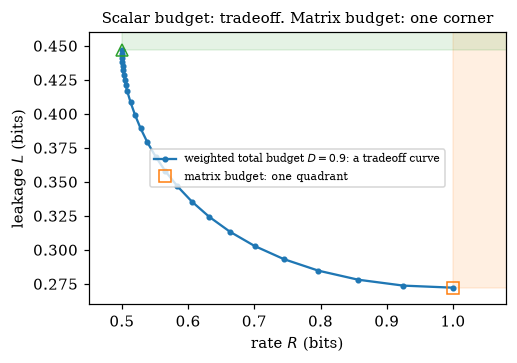

In [4]:
S, F, Q, H, SU, J = coupled(); D = 0.9
pts = [costs(S, J, frontier_point(S, Q, H, SU, D, a)) for a in np.linspace(0, 1, 26)]
fig, ax = plt.subplots(figsize=(4.8, 3.4))
ax.plot([p[0] for p in pts], [p[1] for p in pts], "-o", ms=3, label="weighted total budget $D=0.9$: a tradeoff curve")
for a, mk, col in ((0.0, "s", "tab:orange"), (1.0, "^", "tab:green")):
    r, l = costs(S, J, frontier_point(S, Q, H, SU, D, a))   # a matrix budget Lambda with tr(Q Lambda) = D
    ax.fill_between([r, 1.1], [l, l], [0.47, 0.47], color=col, alpha=0.12)
    ax.plot([r], [l], mk, ms=8, color=col, mfc="none", label="matrix budget: one quadrant" if a == 0 else None)
ax.set_xlim(0.45, 1.08); ax.set_ylim(0.26, 0.46)
ax.set_xlabel("rate $R$ (bits)"); ax.set_ylabel("leakage $L$ (bits)")
ax.set_title("Scalar budget: tradeoff. Matrix budget: one corner", fontsize=10); ax.legend(fontsize=7, loc="center")
fig.tight_layout(); fig.savefig("fig2_scalar_budget.png"); plt.show()

**Figure 3. The observer's geometry changes what an optimal description reads.**
Coupled instance. The best one-dimensional description reduces the error along a direction that turns with the budget
(Theorem turning). A description written for the decoder alone reads a fixed direction at every budget (Proposition
single). No single-party Gaussian rate-distortion problem with a fixed weighted quadratic distortion reproduces the
turning (Corollary nonred); richer single-observer models are not excluded.

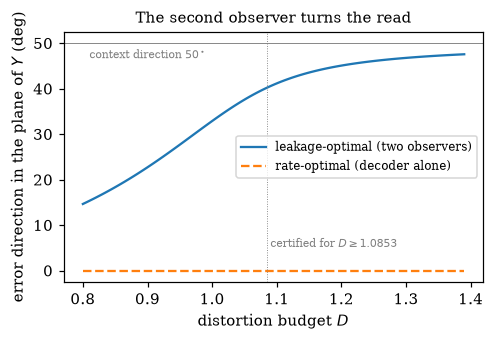

In [5]:
S, F, Q, H, SU, J = coupled()
Ds = np.linspace(0.8, 1.39, 120)
fig, ax = plt.subplots(figsize=(4.6, 3.2))
ax.plot(Ds, [onedim_direction(S, Q, J, F, D) for D in Ds], "-", label="leakage-optimal (two observers)")
ax.plot(Ds, [onedim_direction(S, Q, 0 * J, F, D) for D in Ds], "--", label="rate-optimal (decoder alone)")
ax.axhline(50, color="gray", lw=0.6); ax.text(0.81, 46.5, "context direction $50^\\circ$", fontsize=7, color="gray")
ax.axvline(1.0853, color="gray", lw=0.6, ls=":"); ax.text(1.09, 5, "certified for $D\\geq1.0853$", fontsize=7, color="gray")
ax.set_xlabel("distortion budget $D$"); ax.set_ylabel("error direction in the plane of $Y$ (deg)")
ax.set_title("The second observer turns the read", fontsize=10); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("fig3_turning.png"); plt.show()

**Figure 4. To convey little to an observer, describe what it sees.**
Coupled instance. Every frontier description is reverse water-filling on the decoder's weight tilted by the second
observer's view (Theorem tilted). The tilt strength grows as the weight on leakage grows, and the principal direction of
the tilted weight rotates from the decoder's own direction toward the direction the second observer sees.

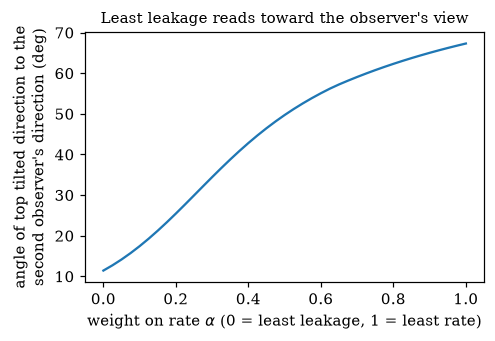

In [6]:
S, F, Q, H, SU, J = coupled(); D = 0.9
Sh = msqrt(S); Qt = Sh @ Q @ Sh; Ht = H @ Sh; Shi = np.linalg.inv(Sh)
alphas = np.linspace(0, 1, 41); angs = []; tilt = []
g = (Ht[0] / np.linalg.norm(Ht[0]))
for a in alphas:
    X = Shi @ frontier_point(S, Q, H, SU, D, a) @ Shi
    T = (1 - a) * Ht.T @ np.linalg.inv(Ht @ X @ Ht.T + SU) @ Ht
    A = Qt + T / max(1e-12, np.trace(Qt))          # direction only: compare tilted weight with Qt
    w, E = np.linalg.eigh(A); e = E[:, -1]
    angs.append(math.degrees(math.acos(min(1, abs(e @ g))))); tilt.append(np.trace(T))
fig, ax = plt.subplots(figsize=(4.6, 3.2))
ax.plot(alphas, angs, "-")
ax.set_xlabel("weight on rate $\\alpha$ (0 = least leakage, 1 = least rate)")
ax.set_ylabel("angle of top tilted direction to the\nsecond observer's direction (deg)")
ax.set_title("Least leakage reads toward the observer's view", fontsize=10)
fig.tight_layout(); fig.savefig("fig4_tilt.png"); plt.show()

# Part 2. The flips on eleven public datasets

Each dataset is split into what the decoder must reconstruct (Y), context the encoder also sees (V), and a view a second
party already holds (S): something plausibly public about the record. All columns are standardized on the training
half; the second party sees its columns through independent Gaussian noise of variance 0.1 in standardized units.

**Pre-specification.** The roles for Energy Efficiency and California Housing were chosen after a first look at those
two datasets. The roles for the other eight were fixed in this generator and committed to the repository before any
outcome on them was computed.

| dataset | rows | decoder reconstructs (Y) | second party sees (S) |
|---|---|---|---|
| UCI Energy Efficiency | 768 | heating load, cooling load | overall height, glazing area |
| California Housing | 20,640 | median house value, median income | latitude, longitude |
| UCI Parkinsons Telemonitoring | 5,875 | motor UPDRS, total UPDRS | age, sex |
| UCI Bike Sharing (hourly) | 17,379 | casual riders, registered riders | season, weather situation |
| UCI Student Performance (Portuguese) | 649 | period-2 grade, final grade | age, sex, urban address |
| UCI Wine Quality (white) | 4,898 | quality | alcohol (printed on the label) |
| UCI Concrete Compressive Strength | 1,030 | strength | age in days |
| scikit-learn Diabetes | 442 | disease progression | age, sex, BMI |
| UCI Abalone | 4,177 | rings | sex, length |
| UCI Auto MPG | 392 | mpg | cylinders, model year |
| Topology Zoo backbones (ICC 2027 artifact) | 175 | false-clear rates V1, V2 under one and two failures | nodes, edges |

The Topology Zoo table is the per-network record of the routing-silence artifact (`results/E6`, `results/E9` at commit
a5bb5a8 of github.com/ahb-sjsu/routing-silence-artifact). Its constant column (witness vacuity) and its duplicate of V1
(reachability vacuity) are not used.

Columns that are exact linear combinations of others are dropped (Energy surface area, Bike total count, one Abalone
sex indicator), and a rank check removes any other context column that is numerically dependent.

In [7]:
def _zip(url):
    return zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url, timeout=120).read()))

def pack(name, Y, V, S_cols, ycols, vcols):
    T = np.column_stack([Y, V]).astype(float); cols = list(ycols) + list(vcols); m = Y.shape[1] if Y.ndim > 1 else 1
    s_idx = [cols.index(c) for c in S_cols]
    # rank guard: drop context columns (never targets or the second party's columns) that are numerically dependent
    keep = list(range(T.shape[1])); Ts = (T - T.mean(0)) / T.std(0)
    for j in range(T.shape[1] - 1, m - 1, -1):
        if j in s_idx: continue
        trial = [k for k in keep if k != j]
        if np.linalg.matrix_rank(Ts[:, keep], tol=1e-8) == np.linalg.matrix_rank(Ts[:, trial], tol=1e-8):
            keep = trial
    T = T[:, keep]; cols = [cols[k] for k in keep]; s_idx = [cols.index(c) for c in S_cols]
    return dict(name=name, T=T, m=m, s_idx=s_idx, cols=cols)

def load_energy():
    z = _zip("https://archive.ics.uci.edu/static/public/242/energy+efficiency.zip")
    df = pd.read_excel(z.open([n for n in z.namelist() if n.endswith(".xlsx")][0])).dropna(axis=1, how="all").dropna()
    X = df.iloc[:, :8].to_numpy(float)
    V = np.delete(X, 1, axis=1)   # surface area = wall + 2 roof exactly
    return pack("Energy", df.iloc[:, 8:10].to_numpy(float), V, ["height", "glazing"], ["heating", "cooling"],
                ["compactness", "wall", "roof", "height", "orientation", "glazing", "glazing dist."])

def load_housing():
    d = fetch_california_housing(); X = d.data
    return pack("Housing", np.column_stack([d.target, X[:, 0]]), X[:, 1:], ["Latitude", "Longitude"],
                ["value", "income"], list(d.feature_names[1:]))

def load_parkinsons():
    df = pd.read_csv(_zip("https://archive.ics.uci.edu/static/public/189/parkinsons+telemonitoring.zip").open("parkinsons_updrs.data"))
    vcols = [c for c in df.columns if c not in ("subject#", "motor_UPDRS", "total_UPDRS")]
    return pack("Parkinsons", df[["motor_UPDRS", "total_UPDRS"]].to_numpy(float), df[vcols].to_numpy(float),
                ["age", "sex"], ["motor UPDRS", "total UPDRS"], vcols)

def load_bike():
    df = pd.read_csv(_zip("https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip").open("hour.csv"))
    vcols = ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit", "temp", "atemp", "hum", "windspeed"]
    return pack("Bike", df[["casual", "registered"]].to_numpy(float), df[vcols].to_numpy(float),
                ["season", "weathersit"], ["casual", "registered"], vcols)

def load_student():
    inner = zipfile.ZipFile(_zip("https://archive.ics.uci.edu/static/public/320/student+performance.zip").open("student.zip"))
    df = pd.read_csv(inner.open("student-por.csv"), sep=";")
    df["sex_F"] = (df["sex"] == "F").astype(float); df["urban"] = (df["address"] == "U").astype(float)
    vcols = ["age", "sex_F", "urban", "Medu", "Fedu", "traveltime", "studytime", "failures", "famrel", "freetime",
             "goout", "Dalc", "Walc", "health", "absences", "G1"]
    return pack("Student", df[["G2", "G3"]].to_numpy(float), df[vcols].to_numpy(float),
                ["age", "sex_F", "urban"], ["G2", "G3"], vcols)

def load_wine():
    df = pd.read_csv(_zip("https://archive.ics.uci.edu/static/public/186/wine+quality.zip").open("winequality-white.csv"), sep=";")
    vcols = [c for c in df.columns if c != "quality"]
    return pack("Wine", df[["quality"]].to_numpy(float), df[vcols].to_numpy(float), ["alcohol"], ["quality"], vcols)

def load_concrete():
    df = pd.read_excel(_zip("https://archive.ics.uci.edu/static/public/165/concrete+compressive+strength.zip").open("Concrete_Data.xls"))
    X = df.to_numpy(float); vcols = ["cement", "slag", "fly ash", "water", "superplasticizer", "coarse agg", "fine agg", "age"]
    return pack("Concrete", X[:, 8:9], X[:, :8], ["age"], ["strength"], vcols)

def load_diabetes_():
    d = load_diabetes()
    return pack("Diabetes", d.target[:, None], d.data, ["age", "sex", "bmi"], ["progression"], list(d.feature_names))

def load_abalone():
    df = pd.read_csv(_zip("https://archive.ics.uci.edu/static/public/1/abalone.zip").open("abalone.data"), header=None)
    df.columns = ["sex", "length", "diameter", "height", "whole", "shucked", "viscera", "shell", "rings"]
    df["male"] = (df["sex"] == "M").astype(float); df["female"] = (df["sex"] == "F").astype(float)   # infant is the base
    vcols = ["male", "female", "length", "diameter", "height", "whole", "shucked", "viscera", "shell"]
    return pack("Abalone", df[["rings"]].to_numpy(float), df[vcols].to_numpy(float), ["male", "female", "length"], ["rings"], vcols)

def load_autompg():
    raw = _zip("https://archive.ics.uci.edu/static/public/9/auto+mpg.zip").open("auto-mpg.data").read().decode()
    rows = [l.split('"')[0].split() for l in raw.strip().splitlines()]
    df = pd.DataFrame([r for r in rows if "?" not in r], columns=["mpg", "cylinders", "displacement", "horsepower",
                                                                 "weight", "acceleration", "year", "origin"]).astype(float)
    vcols = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "year", "origin"]
    return pack("AutoMPG", df[["mpg"]].to_numpy(float), df[vcols].to_numpy(float), ["cylinders", "year"], ["mpg"], vcols)

ZOO = "https://raw.githubusercontent.com/ahb-sjsu/routing-silence-artifact/a5bb5a84811321dfa46ef1db4f1cc45da6c93ff9/results/"
def load_zoo():
    a = pd.read_csv(ZOO + "E6/zoo-resilience-atlas.csv"); e9 = pd.read_csv(ZOO + "E9/E9-summary.csv")
    sp = pd.read_csv(ZOO + "E6/zoo-consumer-spectrum.csv")
    df = a.merge(e9[["name", "rtt0"]], on="name").merge(sp[["name", "V_lat0"]], on="name")
    vcols = ["N", "E", "L", "lam_ht", "bridges", "density", "diameter", "rtt0", "V_lat0"]
    return pack("Zoo", df[["V1", "V2"]].to_numpy(float), df[vcols].to_numpy(float), ["N", "E"], ["V1", "V2"], vcols)

DATA = [f() for f in (load_energy, load_housing, load_parkinsons, load_bike, load_student, load_wine,
                      load_concrete, load_diabetes_, load_abalone, load_autompg, load_zoo)]
for d in DATA:
    print(f"{d['name']:10s} {d['T'].shape}  Y={d['cols'][:d['m']]}  S={[d['cols'][i] for i in d['s_idx']]}")

Energy     (768, 9)  Y=['heating', 'cooling']  S=['height', 'glazing']
Housing    (20640, 9)  Y=['value', 'income']  S=['Latitude', 'Longitude']
Parkinsons (5875, 21)  Y=['motor UPDRS', 'total UPDRS']  S=['age', 'sex']
Bike       (17379, 14)  Y=['casual', 'registered']  S=['season', 'weathersit']
Student    (649, 18)  Y=['G2', 'G3']  S=['age', 'sex_F', 'urban']
Wine       (4898, 12)  Y=['quality']  S=['alcohol']
Concrete   (1030, 9)  Y=['strength']  S=['age']
Diabetes   (442, 11)  Y=['progression']  S=['age', 'sex', 'bmi']
Abalone    (4177, 10)  Y=['rings']  S=['male', 'female', 'length']
AutoMPG    (392, 8)  Y=['mpg']  S=['cylinders', 'year']
Zoo        (175, 11)  Y=['V1', 'V2']  S=['N', 'E']


In [8]:
def lloyd_max(K, iters=500):
    c = norm.ppf((np.arange(K) + 0.5) / K)
    for _ in range(iters):
        a = np.concatenate([[-np.inf], (c[:-1] + c[1:]) / 2, [np.inf]])
        p = norm.cdf(a[1:]) - norm.cdf(a[:-1]); c = (norm.pdf(a[:-1]) - norm.pdf(a[1:])) / p
    return c
BITS = 3; CB = lloyd_max(2 ** BITS); BND = (CB[:-1] + CB[1:]) / 2
GAIN = float(np.sum((norm.cdf(np.r_[BND, np.inf]) - norm.cdf(np.r_[-np.inf, BND])) * CB ** 2))
TAU2 = 0.1

def prepare(d, seed=0):
    r = np.random.default_rng(seed); T = d["T"]; n = len(T); perm = r.permutation(n)
    tr, te = perm[: n // 2], perm[n // 2:]
    mu, sd = T[tr].mean(0), T[tr].std(0); sd[sd == 0] = 1; Ts = (T - mu) / sd
    Sig = np.cov(Ts[tr].T) + 1e-9 * np.eye(T.shape[1])
    return dict(Ts=Ts, tr=tr, te=te, Sig=Sig, rng=r)

def holder(P, s_idx):
    Ts = P["Ts"]; p = Ts.shape[1]
    H = np.zeros((len(s_idx), p)); H[np.arange(len(s_idx)), s_idx] = 1
    S = Ts[:, s_idx] + math.sqrt(TAU2) * P["rng"].normal(size=(len(Ts), len(s_idx)))
    return H, S

def encode(P, b, idx):
    z_tr = P["Ts"][P["tr"]] @ b; z = (P["Ts"][idx] @ b - z_tr.mean()) / z_tr.std()
    return np.searchsorted(BND, z)

ADVERSARIES = {"logistic": lambda: LogisticRegression(max_iter=3000),
               "knn": lambda: KNeighborsClassifier(n_neighbors=50),
               "boosting": lambda: HistGradientBoostingClassifier(max_iter=150, early_stopping=False)}

def leakage_bits(Mtr, Mte, S, P):
    best = math.inf
    for mk in ADVERSARIES.values():
        clf = mk().fit(S[P["tr"]], Mtr); Pr = clf.predict_proba(S[P["te"]]); cols = list(clf.classes_)
        pm = np.array([Pr[i, cols.index(k)] if k in cols else 1e-9 for i, k in enumerate(Mte)])
        best = min(best, float(-np.mean(np.log2(np.clip(pm, 1e-9, 1)))))
    return best

def evaluate(P, b, m, S=None, whole_from=0):
    Ts, tr, te = P["Ts"], P["tr"], P["te"]; K = 2 ** BITS
    Mtr, Mte = encode(P, b, tr), encode(P, b, te)
    means = np.array([Ts[tr][Mtr == k].mean(0) if (Mtr == k).any() else np.zeros(Ts.shape[1]) for k in range(K)])
    err = Ts[te] - means[Mte]
    out = dict(mseT=float(np.mean(np.sum(err[:, whole_from:] ** 2, 1))), distY=float(np.mean(np.sum(err[:, :m] ** 2, 1))))
    pk = np.bincount(Mte, minlength=K) / len(te); out["HM"] = float(-np.sum(pk[pk > 0] * np.log2(pk[pk > 0])))
    if S is not None: out["leak"] = leakage_bits(Mtr, Mte, S, P)
    return out

def consumer_read(Sig, m):
    p = Sig.shape[0]; F = np.zeros((m, p)); F[:, :m] = np.eye(m); Q = F.T @ F
    return F, Q, eigh(Sig @ Q @ Sig, Sig)[1][:, -1]

## Flip A on every dataset

The *energy code* quantizes the top principal component of all standardized columns, the best one-dimensional read of
the whole source. The *consumer code* quantizes the decoder's best read. **Prediction (training half):** the angle between
them in the Sigma metric; a flip needs it to be nonzero. **Outcome (held-out):** a flip occurs when the consumer code has
higher whole-source MSE and lower decoder MSE.

**Result.** Flip A occurred in all 11 datasets.

In [9]:
rowsA = []
for d in DATA:
    P = prepare(d); Sig = P["Sig"]; m = d["m"]; F, Q, b_R = consumer_read(Sig, m)
    b_pca = np.linalg.eigh(Sig)[1][:, -1]
    cosA = abs(b_pca @ Sig @ b_R) / math.sqrt((b_pca @ Sig @ b_pca) * (b_R @ Sig @ b_R))
    e_p, e_r = evaluate(P, b_pca, m), evaluate(P, b_R, m)
    flip = e_r["mseT"] > e_p["mseT"] and e_r["distY"] < e_p["distY"]
    rowsA.append(dict(name=d["name"], angle=math.degrees(math.acos(min(1, cosA))), e_p=e_p, e_r=e_r, flip=flip))
    print(f"{d['name']:10s} angle {rowsA[-1]['angle']:5.1f} deg | whole-source MSE {e_p['mseT']:.3f} -> {e_r['mseT']:.3f} | "
          f"decoder MSE {e_p['distY']:.3f} -> {e_r['distY']:.3f} | flip {'yes' if flip else 'no'}")
print("Flip A occurred in", sum(r["flip"] for r in rowsA), "of", len(rowsA), "datasets")

Energy     angle  15.2 deg | whole-source MSE 3.891 -> 4.117 | decoder MSE 0.195 -> 0.068 | flip yes
Housing    angle  61.8 deg | whole-source MSE 12.836 -> 13.742 | decoder MSE 1.416 -> 0.389 | flip yes
Parkinsons angle  82.6 deg | whole-source MSE 11.114 -> 19.039 | decoder MSE 1.944 -> 0.092 | flip yes
Bike       angle  37.5 deg | whole-source MSE 10.469 -> 11.543 | decoder MSE 0.946 -> 0.563 | flip yes
Student    angle  25.6 deg | whole-source MSE 16.052 -> 16.947 | decoder MSE 0.552 -> 0.118 | flip yes
Wine       angle  65.4 deg | whole-source MSE 8.605 -> 10.355 | decoder MSE 0.828 -> 0.008 | flip yes
Concrete   angle  68.7 deg | whole-source MSE 5.969 -> 7.421 | decoder MSE 0.791 -> 0.030 | flip yes
Diabetes   angle  49.7 deg | whole-source MSE 7.112 -> 8.475 | decoder MSE 0.569 -> 0.029 | flip yes
Abalone    angle  49.8 deg | whole-source MSE 3.106 -> 5.709 | decoder MSE 0.662 -> 0.058 | flip yes
AutoMPG    angle  26.2 deg | whole-source MSE 2.671 -> 3.409 | decoder MSE 0.253 -

**Boundary sweep for Flip A, all datasets.** For each dataset, 30 decoder tasks interpolate from the energy projection
itself to random combinations of all columns. Each point is one task: the training half predicts the angle, the held-out
half measures the two halves of the flip.

**Result.** In every dataset both halves are near zero at small predicted angle and grow with it. The decoder half is
clean; the largest decoder gain below 10 degrees is 0.071 (Zoo). The whole-source half is noisier: some tasks below 30
degrees have a negative whole-source loss, so no flip (up to 8 of 30 tasks in Housing, 7 in Energy and Zoo).

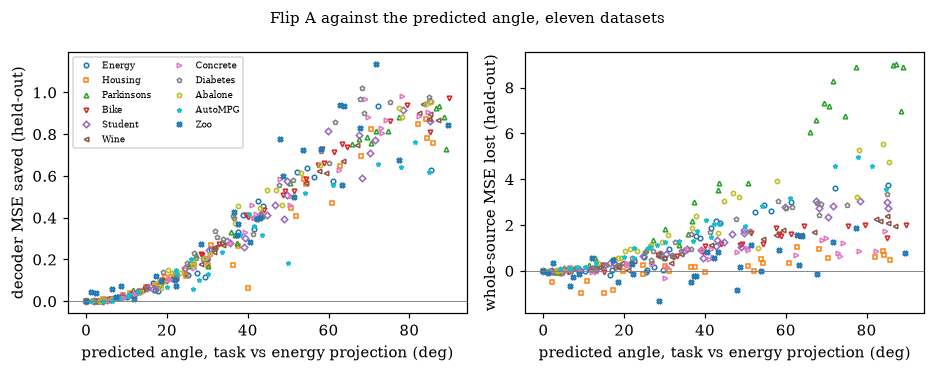

Energy     flip in 22/30 tasks; below 10 deg: max |gain| 0.018; tasks below 30 deg with negative whole-source loss: 7
Housing    flip in 18/30 tasks; below 10 deg: max |gain| 0.030; tasks below 30 deg with negative whole-source loss: 8
Parkinsons flip in 26/30 tasks; below 10 deg: max |gain| 0.006; tasks below 30 deg with negative whole-source loss: 2
Bike       flip in 27/30 tasks; below 10 deg: max |gain| 0.020; tasks below 30 deg with negative whole-source loss: 2
Student    flip in 28/30 tasks; below 10 deg: max |gain| 0.023; tasks below 30 deg with negative whole-source loss: 1
Wine       flip in 29/30 tasks; below 10 deg: max |gain| 0.017; tasks below 30 deg with negative whole-source loss: 0
Concrete   flip in 24/30 tasks; below 10 deg: max |gain| 0.017; tasks below 30 deg with negative whole-source loss: 4
Diabetes   flip in 26/30 tasks; below 10 deg: max |gain| 0.015; tasks below 30 deg with negative whole-source loss: 3
Abalone    flip in 29/30 tasks; below 10 deg: max |gain|

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4)); markers = "os^vD<>ph*X"
allA = []
for d, mk in zip(DATA, markers):
    P = prepare(d, seed=3); Sig = P["Sig"]; p = Sig.shape[0]; b_pca = np.linalg.eigh(Sig)[1][:, -1]
    xs, gain, loss = [], [], []
    for k in range(30):
        r = np.random.default_rng(100 + k).normal(size=p); t = k / 29
        w = (1 - t) * b_pca / np.sqrt(b_pca @ Sig @ b_pca) + t * r / np.sqrt(r @ Sig @ r)
        cosA = abs(b_pca @ Sig @ w) / math.sqrt((b_pca @ Sig @ b_pca) * (w @ Sig @ w))
        Pw = dict(P); Pw["Ts"] = np.column_stack([P["Ts"] @ w / math.sqrt(w @ Sig @ w), P["Ts"]])
        e_p = evaluate(Pw, np.r_[0.0, b_pca], 1, whole_from=1); e_r = evaluate(Pw, np.r_[1.0, np.zeros(p)], 1, whole_from=1)
        xs.append(math.degrees(math.acos(min(1, cosA)))); gain.append(e_p["distY"] - e_r["distY"]); loss.append(e_r["mseT"] - e_p["mseT"])
    allA.append((d["name"], xs, gain, loss))
    axes[0].plot(xs, gain, mk, ms=3, mfc="none", label=d["name"]); axes[1].plot(xs, loss, mk, ms=3, mfc="none")
for ax, lab in zip(axes, ("decoder MSE saved (held-out)", "whole-source MSE lost (held-out)")):
    ax.axhline(0, color="gray", lw=0.6); ax.set_xlabel("predicted angle, task vs energy projection (deg)"); ax.set_ylabel(lab)
axes[0].legend(fontsize=6, ncol=2)
fig.suptitle("Flip A against the predicted angle, eleven datasets", fontsize=10)
fig.tight_layout(); fig.savefig("fig5_flipA_boundary.png"); plt.show()
for name, xs, gain, loss in allA:
    xs, gain, loss = map(np.array, (xs, gain, loss))
    print(f"{name:10s} flip in {int(np.sum((gain > 0) & (loss > 0)))}/30 tasks; below 10 deg: max |gain| {np.max(np.abs(gain[xs < 10])) if np.any(xs < 10) else float('nan'):.3f}; "
          f"tasks below 30 deg with negative whole-source loss: {int(np.sum((xs < 30) & (loss < 0)))}")

## Flip B on every dataset

Both codes use the same 3-bit quantizer on one projection. The *principal code* reads the decoder's best projection.
The *aware code* reads the projection that maximizes the squared multiple correlation with the second party's view,
subject to the decoder budget placed a fraction f of the way from the principal code's distortion to the trivial
distortion. **Prediction (training half):** the squared correlation of the view with the principal read. **Outcome
(held-out):** a flip occurs when the aware code has higher decoder MSE and lower leakage under the best of three
adversaries.

*Record of a refuted prediction.* An earlier version of this notebook predicted no flip at all when the predicted
correlation is zero. That was refuted on Energy Efficiency with an orientation-only view (0.58 bits removed at f = 0.7):
with slack in the budget, the aware code can read a direction correlated with what the second party sees, which lowers
leakage (the paper's Corollary augmented). The paper's boundary concerns the optimal descriptions at the same budget;
its data analogue is the onset test at the end.

**Result.** Flip B occurred at all three budget fractions in 8 of 11 datasets and at two of three in Bike. It failed
in Wine and in the Topology Zoo table, where the aware codes leaked more than the principal code under the best adversary.
The aware projection is chosen with a Gaussian proxy (the squared multiple correlation); Wine's target is a discrete
score, and the Zoo table has 175 rows. These are possible reasons, not tested here.

In [11]:
def aware_direction(P, F, Hm, D0, ndir=200000):
    Sig = P["Sig"]; p = Sig.shape[0]; SS = Hm @ Sig @ Hm.T + TAU2 * np.eye(Hm.shape[0])
    B = P["rng"].normal(size=(ndir, p)); sd = np.sqrt(np.einsum('ij,jk,ik->i', B, Sig, B))
    cYZ = (B @ Sig @ F.T) / sd[:, None]; CSZ = (B @ Sig @ Hm.T) / sd[:, None]
    R2 = np.einsum('ij,jk,ik->i', CSZ, np.linalg.inv(SS), CSZ)
    need = (np.trace(F @ Sig @ F.T) - D0) / GAIN
    feas = np.einsum('ij,ij->i', cYZ, cYZ) >= need
    return B[int(np.argmax(np.where(feas, R2, -1)))]

def flipB(d, s_idx, fracs=(0.15, 0.4, 0.7), seed=0):
    P = prepare(d, seed=seed); Sig = P["Sig"]; m = d["m"]; F, Q, b_R = consumer_read(Sig, m)
    Hm, S = holder(P, s_idx)
    SS = Hm @ Sig @ Hm.T + TAU2 * np.eye(len(s_idx)); c = Hm @ Sig @ b_R / math.sqrt(b_R @ Sig @ b_R)
    R2pred = float(c @ np.linalg.inv(SS) @ c)
    e_R = evaluate(P, b_R, m, S); trY = float(np.trace(F @ Sig @ F.T))
    DR = trY - GAIN * float((F @ Sig @ b_R) @ (F @ Sig @ b_R)) / float(b_R @ Sig @ b_R)
    rows = []
    for f in fracs:
        D0 = DR + f * (trY - DR); e_a = evaluate(P, aware_direction(P, F, Hm, D0), m, S)
        rows.append((f, D0, e_R, e_a))
    return R2pred, rows

resultsB = {}
for d in DATA:
    R2pred, rows = flipB(d, d["s_idx"]); resultsB[d["name"]] = (R2pred, rows)
    flips = [(e_a["distY"] > e_R["distY"]) and (e_a["leak"] < e_R["leak"]) for f, D0, e_R, e_a in rows]
    e_R = rows[0][2]
    print(f"{d['name']:10s} pred corr^2 {R2pred:.3f} | principal: decoder MSE {e_R['distY']:.3f} leak {e_R['leak']:.3f} b | aware leak at f=0.15/0.4/0.7: "
          + " / ".join(f"{r[3]['leak']:.3f}" for r in rows) + f" | flips {sum(flips)}/3")
print("Flip B occurred at all three budgets in", sum(all((r[3]['distY'] > r[2]['distY']) and (r[3]['leak'] < r[2]['leak']) for r in v[1])
      for v in resultsB.values()), "of", len(DATA), "datasets")

Energy     pred corr^2 0.799 | principal: decoder MSE 0.068 leak 1.344 b | aware leak at f=0.15/0.4/0.7: 0.353 / 0.601 / 0.269 | flips 3/3


Housing    pred corr^2 0.069 | principal: decoder MSE 0.389 leak 2.568 b | aware leak at f=0.15/0.4/0.7: 2.458 / 2.307 / 1.889 | flips 3/3


Parkinsons pred corr^2 0.091 | principal: decoder MSE 0.092 leak 2.705 b | aware leak at f=0.15/0.4/0.7: 2.545 / 2.055 / 1.665 | flips 3/3


Bike       pred corr^2 0.047 | principal: decoder MSE 0.563 leak 2.250 b | aware leak at f=0.15/0.4/0.7: 2.570 / 2.239 / 1.884 | flips 2/3


Student    pred corr^2 0.058 | principal: decoder MSE 0.118 leak 2.709 b | aware leak at f=0.15/0.4/0.7: 2.614 / 2.383 / 2.081 | flips 3/3


...

Concrete   pred corr^2 0.084 | principal: decoder MSE 0.030 leak 2.629 b | aware leak at f=0.15/0.4/0.7: 2.562 / 2.219 / 1.858 | flips 3/3


Diabetes   pred corr^2 0.331 | principal: decoder MSE 0.029 leak 2.532 b | aware leak at f=0.15/0.4/0.7: 2.419 / 1.954 / 1.676 | flips 3/3


Abalone    pred corr^2 0.317 | principal: decoder MSE 0.058 leak 2.230 b | aware leak at f=0.15/0.4/0.7: 1.951 / 1.551 / 1.096 | flips 3/3


AutoMPG    pred corr^2 0.683 | principal: decoder MSE 0.061 leak 2.169 b | aware leak at f=0.15/0.4/0.7: 1.509 / 1.272 / 1.273 | flips 3/3


Zoo        pred corr^2 0.024 | principal: decoder MSE 0.034 leak 2.091 b | aware leak at f=0.15/0.4/0.7: 2.629 / 3.176 / 2.411 | flips 0/3
Flip B occurred at all three budgets in 8 of 11 datasets


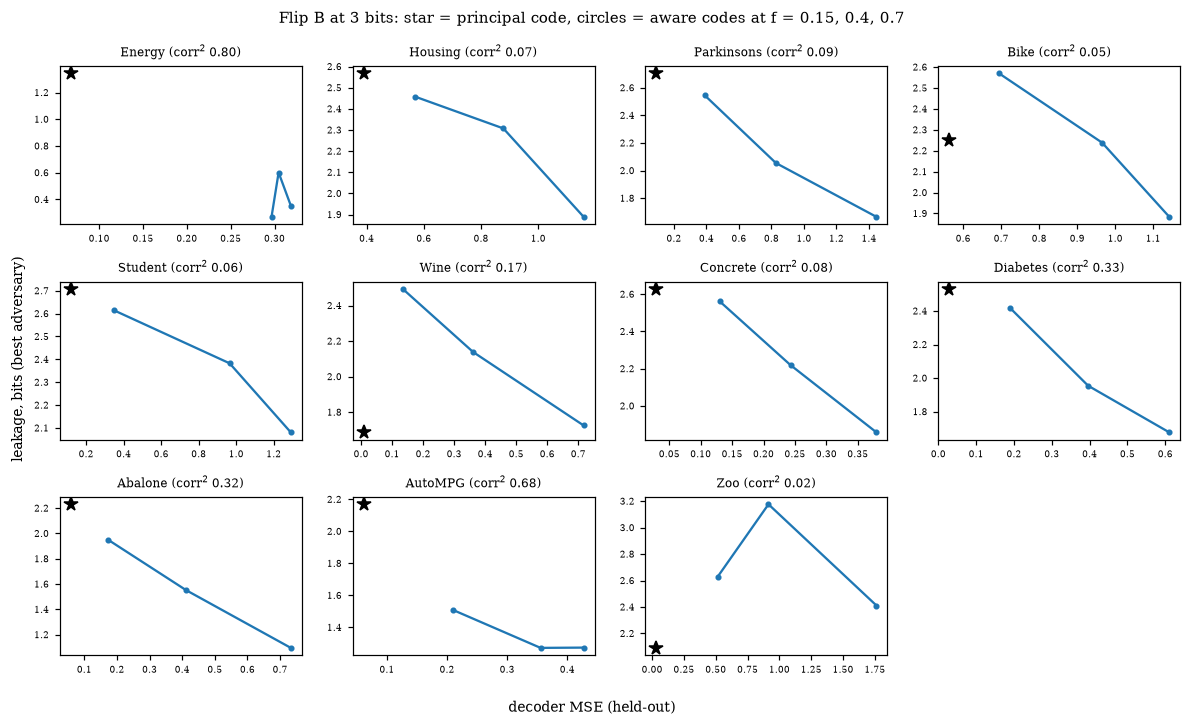

In [12]:
fig, axes = plt.subplots(3, 4, figsize=(11, 6.6)); axes = axes.ravel(); axes[-1].axis("off")
for ax, d in zip(axes, DATA):
    R2pred, rows = resultsB[d["name"]]; e_R = rows[0][2]
    ax.plot([e_R["distY"]], [e_R["leak"]], "k*", ms=9)
    ax.plot([r[3]["distY"] for r in rows], [r[3]["leak"] for r in rows], "o-", ms=3)
    ax.set_title(f"{d['name']} (corr$^2$ {R2pred:.2f})", fontsize=8); ax.tick_params(labelsize=6)
fig.supxlabel("decoder MSE (held-out)", fontsize=9); fig.supylabel("leakage, bits (best adversary)", fontsize=9)
fig.suptitle("Flip B at 3 bits: star = principal code, circles = aware codes at f = 0.15, 0.4, 0.7", fontsize=10)
fig.tight_layout(); fig.savefig("fig6_flipB.png"); plt.show()

**Boundary sweep for Flip B, all datasets.** Each context column of each dataset, in turn, is the second party's view.
The training half predicts its squared correlation with the decoder's principal read; the held-out half measures the
leakage removed by the aware code at f = 0.4.

**Result.** Over 115 (dataset, view) pairs the predicted correlation ranks the leakage removed with Spearman
correlation 0.62. Views predicted uncorrelated (corr^2 < 0.01, n = 37) remove a median 0.17 bits; views with corr^2 >= 0.1
(n = 36) remove a median 0.56 bits. Points below zero come mostly from Wine, Zoo, and Bike, where the aware code leaked more.

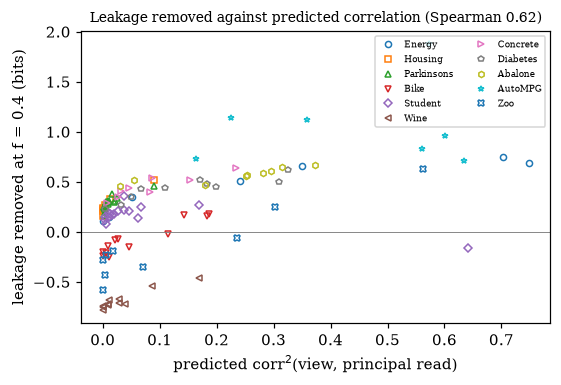

115 (dataset, view) pairs; Spearman correlation of prediction and outcome 0.624
views with predicted corr^2 < 0.01: n=37, median leakage removed 0.166 b; views with corr^2 >= 0.1: n=36, median 0.560 b


In [13]:
sweep = {}; xs_all, ys_all = [], []
fig, ax = plt.subplots(figsize=(5.2, 3.6))
for d, mk in zip(DATA, markers):
    pts = []
    for j in range(d["m"], d["T"].shape[1]):
        R2pred, rows = flipB(d, [j], fracs=(0.4,))
        pts.append((d["cols"][j], R2pred, rows[0][2]["leak"] - rows[0][3]["leak"]))
    sweep[d["name"]] = pts; xs_all += [t[1] for t in pts]; ys_all += [t[2] for t in pts]
    ax.plot([t[1] for t in pts], [t[2] for t in pts], mk, ms=4, mfc="none", label=d["name"])
ax.axhline(0, color="gray", lw=0.6); ax.set_xlabel("predicted corr$^2$(view, principal read)")
ax.set_ylabel("leakage removed at f = 0.4 (bits)"); ax.legend(fontsize=6, ncol=2)
rho_s = pd.Series(xs_all).corr(pd.Series(ys_all), method="spearman")
ax.set_title(f"Leakage removed against predicted correlation (Spearman {rho_s:.2f})", fontsize=9)
fig.tight_layout(); fig.savefig("fig7_flipB_boundary.png"); plt.show()
print(f"{len(xs_all)} (dataset, view) pairs; Spearman correlation of prediction and outcome {rho_s:.3f}")
lo = [y for x, y in zip(xs_all, ys_all) if x < 0.01]; hi = [y for x, y in zip(xs_all, ys_all) if x >= 0.1]
print(f"views with predicted corr^2 < 0.01: n={len(lo)}, median leakage removed {np.median(lo):.3f} b; "
      f"views with corr^2 >= 0.1: n={len(hi)}, median {np.median(hi):.3f} b")

## The onset of Flip B (fresh split)

Near the principal read, the decoder's distortion rises only to second order. If the second party's view is correlated
with the principal read, leakage falls to first order; if not, only to second order. So at small slack a correlated view
should shed leakage and an uncorrelated one should shed almost none. For each dataset, the most and the least correlated
single-column view from the sweep are tested on a split drawn with a new seed at f = 0.03 and 0.06. (An earlier version
also predicted log-log slopes of 1/2 and 1; with a sampled aware direction and a quantizer the measured slopes did not
match, and that prediction is withdrawn.)

**Result: refuted.** The correlated view shed more leakage at small slack in only 4 of 11 datasets, and in several
datasets the aware code leaked more than the principal code at small slack. The onset prediction, formulated after the
first refutation on two datasets, does not survive eleven.

Energy     correlated view         height (corr^2 0.748): removed +0.114, +0.466 b | uncorrelated view    orientation (corr^2 0.000): removed -0.035, +0.008 b


Housing    correlated view       AveRooms (corr^2 0.090): removed +0.049, +0.192 b | uncorrelated view       HouseAge (corr^2 0.000): removed +0.016, +0.000 b


Parkinsons correlated view            age (corr^2 0.090): removed +0.073, +0.017 b | uncorrelated view      test_time (corr^2 0.003): removed +0.148, +0.037 b


Bike       correlated view           temp (corr^2 0.187): removed -0.586, -0.633 b | uncorrelated view        holiday (corr^2 0.000): removed -0.552, -0.496 b


Student    correlated view             G1 (corr^2 0.641): removed -0.709, -0.828 b | uncorrelated view         famrel (corr^2 0.004): removed +0.229, -0.055 b


...

Concrete   correlated view         cement (corr^2 0.233): removed +0.005, +0.072 b | uncorrelated view        fly ash (corr^2 0.008): removed +0.009, +0.016 b


Diabetes   correlated view            bmi (corr^2 0.325): removed -0.131, -0.174 b | uncorrelated view            sex (corr^2 0.004): removed +0.027, -0.032 b


Abalone    correlated view          shell (corr^2 0.373): removed +0.012, +0.135 b | uncorrelated view           male (corr^2 0.031): removed +0.063, +0.014 b


AutoMPG    correlated view         weight (corr^2 0.635): removed +0.094, +0.181 b | uncorrelated view   acceleration (corr^2 0.163): removed +0.156, +0.183 b


Zoo        correlated view         lam_ht (corr^2 0.562): removed -0.375, -0.818 b | uncorrelated view              E (corr^2 0.000): removed -0.350, -0.065 b


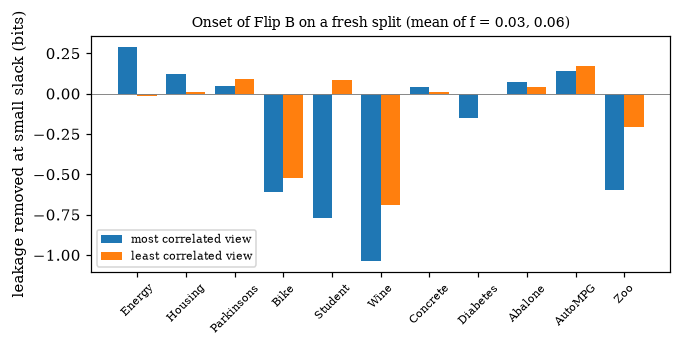

correlated view sheds more leakage at small slack in 4 of 11 datasets


In [14]:
def onset(d, s_idx, fracs=(0.03, 0.06), seed=7):
    P = prepare(d, seed=seed); Sig = P["Sig"]; m = d["m"]; F, Q, b_R = consumer_read(Sig, m); Hm, S = holder(P, s_idx)
    e_R = evaluate(P, b_R, m, S); trY = float(np.trace(F @ Sig @ F.T))
    DR = trY - GAIN * float((F @ Sig @ b_R) @ (F @ Sig @ b_R)) / float(b_R @ Sig @ b_R)
    return [e_R["leak"] - evaluate(P, aware_direction(P, F, Hm, DR + f * (trY - DR)), m, S)["leak"] for f in fracs]

rowsO = []
for d in DATA:
    pts = sweep[d["name"]]; hi = max(pts, key=lambda t: t[1]); lo = min(pts, key=lambda t: t[1])
    oh, ol = onset(d, [d["cols"].index(hi[0])]), onset(d, [d["cols"].index(lo[0])])
    rowsO.append((d["name"], hi, lo, oh, ol))
    print(f"{d['name']:10s} correlated view {hi[0]:>14s} (corr^2 {hi[1]:.3f}): removed {oh[0]:+.3f}, {oh[1]:+.3f} b | "
          f"uncorrelated view {lo[0]:>14s} (corr^2 {lo[1]:.3f}): removed {ol[0]:+.3f}, {ol[1]:+.3f} b")
fig, ax = plt.subplots(figsize=(6.2, 3.2)); xi = np.arange(len(rowsO))
ax.bar(xi - 0.2, [np.mean(r[3]) for r in rowsO], 0.4, label="most correlated view")
ax.bar(xi + 0.2, [np.mean(r[4]) for r in rowsO], 0.4, label="least correlated view")
ax.axhline(0, color="gray", lw=0.6); ax.set_xticks(xi); ax.set_xticklabels([r[0] for r in rowsO], rotation=45, fontsize=7)
ax.set_ylabel("leakage removed at small slack (bits)"); ax.legend(fontsize=7)
ax.set_title("Onset of Flip B on a fresh split (mean of f = 0.03, 0.06)", fontsize=9)
fig.tight_layout(); fig.savefig("fig8_flipB_onset.png"); plt.show()
wins = sum(np.mean(r[3]) > np.mean(r[4]) for r in rowsO)
print(f"correlated view sheds more leakage at small slack in {wins} of {len(rowsO)} datasets")

## What the data show, and what they do not

* Predictions use only second-order statistics of the training half. Outcomes use real 3-bit quantizers,
  reconstructions learned on the training half, and held-out samples.
* Leakage is the held-out cross-entropy of the best of three classifiers predicting the code index from the second
  party's view. It upper-bounds H(M|S). A better adversary could lower both codes' numbers; the flip is the ordering
  under the best adversary tried.
* Matched rate means the same 3-bit index for both codes. Empirical index entropies are printed beside the leakages.
* The Gaussian model chooses the aware projection. Nothing in the measured outcomes assumes Gaussianity.
* Two predictions made earlier in this notebook's history were refuted and are recorded above: a finite-budget boundary
  for Flip B, and log-log onset slopes of 1/2 and 1.

**Tally on the pre-specified run** (roles pushed to branch prespec/ot-notebook-2026-10-01 at 2026-10-02 05:43:31 UTC;
this run 05:44:42 to 06:05:54 UTC): Flip A 11 of 11 datasets; its boundary holds in every dataset; Flip B 8 of 11 at all
budgets, failing in Wine and Zoo; the Flip B sweep is graded (Spearman 0.62) with a residual at zero correlation; the onset
prediction is refuted (4 of 11). Markdown result statements and the two corrected captions were edited after execution;
code cells and outputs are unchanged.